<a href="https://colab.research.google.com/github/SonicWD/PROCESAMIENTO-DE-LENGUAJE-NATURAL/blob/main/REA1_Embeddings/Laboratorio_Transforma_Texto_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Laboratorio · Transforma texto en embeddings

**REA 1 · Procesamiento de Lenguaje Natural** · CAD2202023206 · EIAIIPA2026  
**Estudiante:** Wilson Alfonso Díaz Capador  
**Repositorio:** https://github.com/SonicWD/PROCESAMIENTO-DE-LENGUAJE-NATURAL

Este cuaderno recorre el proceso completo: texto crudo → tokens → vectores dispersos (one-hot, TF-IDF) → **embeddings densos** (LSA y PPMI+SVD) → similitud coseno → búsqueda semántica y visualización PCA.


## 0. Entorno

En Colab ejecute la celda siguiente. En local: `pip install -r requirements.txt`.


In [1]:
%pip install -q scikit-learn matplotlib pandas numpy


In [2]:
from __future__ import annotations
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})
print("Listo. Semilla =", SEED)


Listo. Semilla = 42


## 1. ¿Qué es un embedding?

Un **embedding** es un vector de números reales que representa una unidad de lenguaje (palabra, oración o documento) de modo que **la geometría del espacio** refleje relaciones semánticas: textos parecidos quedan cerca; textos de temas distintos quedan lejos (Mikolov et al., 2013; Jurafsky y Martin, 2023).

El proceso típico es:

1. **Normalizar** el texto (minúsculas, puntuación, stopwords).
2. **Tokenizar** (separar unidades).
3. Construir una **representación numérica**:
   - *Dispersa y alta*: one-hot, bolsa de palabras, TF-IDF. Cada dimensión es un término del vocabulario. Dos oraciones sin palabras en común tienen similitud 0, aunque signifiquen lo mismo.
   - *Densa y baja*: LSA (Deerwester et al., 1990), Word2Vec, GloVe, BERT. Pocas dimensiones (aquí 3) capturan factores latentes: “tema vivienda”, “tema NLP”, etc.
4. **Comparar** con similitud coseno: \(\cos(u,v) = (u\cdot v)/(\lVert u\rVert\lVert v\rVert)\).
5. **Usar** el espacio: ranking de documentos, clustering, visualización.

Este laboratorio no llama a una API de pago: todo se calcula en el notebook con scikit-learn, para que sea reproducible en GitHub y Colab.


## 2. Corpus propio (tres temas)


In [3]:
DOCUMENTOS = [
    {"id": "D1", "tema": "NLP", "texto": "El procesamiento de lenguaje natural convierte oraciones en vectores densos llamados embeddings."},
    {"id": "D2", "tema": "NLP", "texto": "Los embeddings de lenguaje natural representan el significado del texto para comparar semántica y no solo palabras."},
    {"id": "D3", "tema": "NLP", "texto": "Word2Vec y BERT aprenden embeddings y representaciones vectoriales del lenguaje natural a partir de corpus."},
    {"id": "D4", "tema": "Vivienda", "texto": "El apartamento en Bogotá tiene tres habitaciones, garaje y un precio cercano a cuatrocientos millones."},
    {"id": "D5", "tema": "Vivienda", "texto": "Busco un apartamento residencial con parqueadero en Bogotá, de tres habitaciones y buen precio."},
    {"id": "D6", "tema": "Vivienda", "texto": "La casa en arriendo en Bogotá incluye tres habitaciones, dos baños y está cerca del TransMilenio."},
    {"id": "D7", "tema": "Deporte", "texto": "El equipo de fútbol ganó el partido con dos goles en el segundo tiempo."},
    {"id": "D8", "tema": "Deporte", "texto": "Los jugadores del equipo de fútbol entrenaron táctica antes del partido del campeonato."},
]
df = pd.DataFrame(DOCUMENTOS)
df


,id,tema,texto
0,D1,NLP,El procesamiento de lenguaje natural convierte...
1,D2,NLP,Los embeddings de lenguaje natural representan...
2,D3,NLP,Word2Vec y BERT aprenden embeddings y represen...
3,D4,Vivienda,El apartamento en Bogotá tiene tres habitacion...
4,D5,Vivienda,Busco un apartamento residencial con parqueade...
5,D6,Vivienda,La casa en arriendo en Bogotá incluye tres hab...
6,D7,Deporte,El equipo de fútbol ganó el partido con dos go...
7,D8,Deporte,Los jugadores del equipo de fútbol entrenaron ...


## 3. Preprocesamiento


In [4]:
STOPWORDS_ES = {
    "el", "la", "los", "las", "un", "una", "unos", "unas", "de", "del", "al",
    "y", "o", "en", "con", "por", "para", "a", "que", "se", "su", "sus",
    "es", "son", "está", "estan", "este", "esta", "esto", "como", "más",
    "mas", "no", "si", "sí",
}

def normalizar(texto: str) -> str:
    texto = texto.lower()
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)
    tokens = [t for t in texto.split() if t and t not in STOPWORDS_ES]
    return " ".join(tokens)

df["norm"] = df["texto"].map(normalizar)
df[["id", "tema", "norm"]]


,id,tema,norm
0,D1,NLP,procesamiento lenguaje natural convierte oraci...
1,D2,NLP,embeddings lenguaje natural representan signif...
2,D3,NLP,word vec bert aprenden embeddings representaci...
3,D4,Vivienda,apartamento bogotá tiene tres habitaciones gar...
4,D5,Vivienda,busco apartamento residencial parqueadero bogo...
5,D6,Vivienda,casa arriendo bogotá incluye tres habitaciones...
6,D7,Deporte,equipo fútbol ganó partido dos goles segundo t...
7,D8,Deporte,jugadores equipo fútbol entrenaron táctica ant...


## 4. Representaciones dispersas: one-hot y TF-IDF

One-hot por documento marca presencia de cada término. TF-IDF pondera términos frecuentes en el documento y raros en el corpus (Salton y Buckley, 1988). Ambos viven en \(\mathbb{R}^{|V|}\) (aquí vocabulario ≈ 57).


In [5]:
docs = df["norm"].tolist()
ids = df["id"].tolist()
temas = df["tema"].tolist()

vocab = sorted({tok for doc in docs for tok in doc.split()})
idx = {w: i for i, w in enumerate(vocab)}
X_oh = np.zeros((len(docs), len(vocab)))
for i, doc in enumerate(docs):
    for tok in set(doc.split()):
        X_oh[i, idx[tok]] = 1.0

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(docs).toarray()
print("Dimensión one-hot / TF-IDF:", X_oh.shape[1])
print("Ejemplo D1 (primeros 12 pesos TF-IDF):")
print(np.round(X_tfidf[0, :12], 3))


Dimensión one-hot / TF-IDF: 57
Ejemplo D1 (primeros 12 pesos TF-IDF):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## 5. Embeddings densos

**LSA:** SVD sobre la matriz TF-IDF. Cada documento pasa de 57 dimensiones a 3 factores latentes (Deerwester et al., 1990).

**PPMI + SVD:** se cuenta coocurrencia en ventana 2, se transforma a *Positive Pointwise Mutual Information* y se reduce con SVD. Es la familia de métodos de Count-based embeddings, emparentada con GloVe (Pennington et al., 2014). El embedding de un documento es la **media** de los vectores de sus palabras.


In [6]:
# LSA
svd = TruncatedSVD(n_components=3, random_state=SEED)
X_lsa = svd.fit_transform(X_tfidf)
print("Varianza explicada LSA:", np.round(svd.explained_variance_ratio_, 4))
print("Suma:", round(float(svd.explained_variance_ratio_.sum()), 4))

# PPMI + SVD (palabra) y media (documento)
def coocurrencia(docs_norm, vocab, ventana=2):
    ix = {w: i for i, w in enumerate(vocab)}
    C = np.zeros((len(vocab), len(vocab)))
    for doc in docs_norm:
        toks = doc.split()
        for i, w in enumerate(toks):
            for j in range(max(0, i - ventana), min(len(toks), i + ventana + 1)):
                if i != j:
                    C[ix[w], ix[toks[j]]] += 1.0
    return C

def ppmi(C, eps=1e-8):
    p = C / (C.sum() + eps)
    pmi = np.log((p + eps) / (p.sum(1, keepdims=True) * p.sum(0, keepdims=True) + eps))
    return np.maximum(pmi, 0.0)

C = coocurrencia(docs, vocab)
E_pal = TruncatedSVD(n_components=3, random_state=SEED).fit_transform(ppmi(C))
X_ppmi = np.vstack([
    np.mean([E_pal[idx[t]] for t in d.split() if t in idx], axis=0)
    for d in docs
])
print("Forma embeddings LSA:", X_lsa.shape, "| PPMI:", X_ppmi.shape)


Varianza explicada LSA: [0.1317 0.1303 0.163 ]
Suma: 0.425
Forma embeddings LSA: (8, 3) | PPMI: (8, 3)


## 6. Similitud coseno y separación por tema


In [7]:
def media_pares(sim, temas, mismo):
    vals = []
    n = len(temas)
    for i in range(n):
        for j in range(i + 1, n):
            if (temas[i] == temas[j]) == mismo:
                vals.append(sim[i, j])
    return float(np.mean(vals))

filas = []
for nombre, X in [("one-hot", X_oh), ("TF-IDF", X_tfidf), ("LSA", X_lsa), ("PPMI+SVD", X_ppmi)]:
    sim = cosine_similarity(X)
    filas.append({
        "representación": nombre,
        "dim": X.shape[1],
        "coseno intra-tema": round(media_pares(sim, temas, True), 4),
        "coseno inter-tema": round(media_pares(sim, temas, False), 4),
    })
tabla = pd.DataFrame(filas)
tabla


,representación,dim,coseno intra-tema,coseno inter-tema
0,one-hot,57,0.3460,0.0053
1,TF-IDF,57,0.2363,0.0045
2,LSA,3,0.9879,0.0155
3,PPMI+SVD,3,0.9872,0.0351


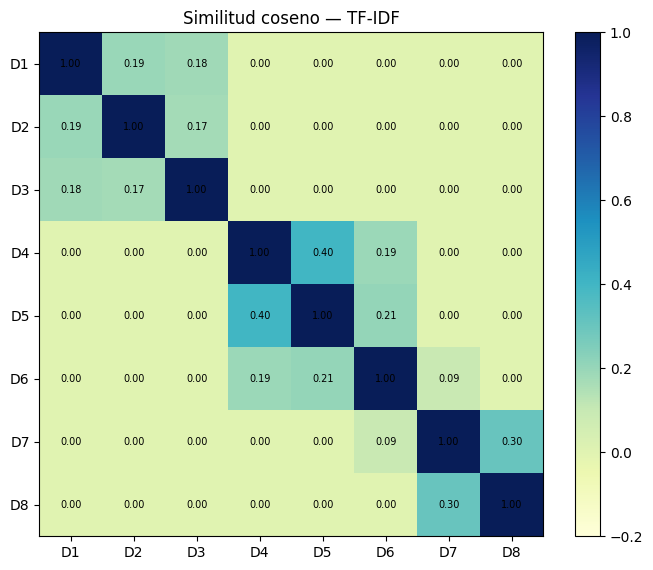

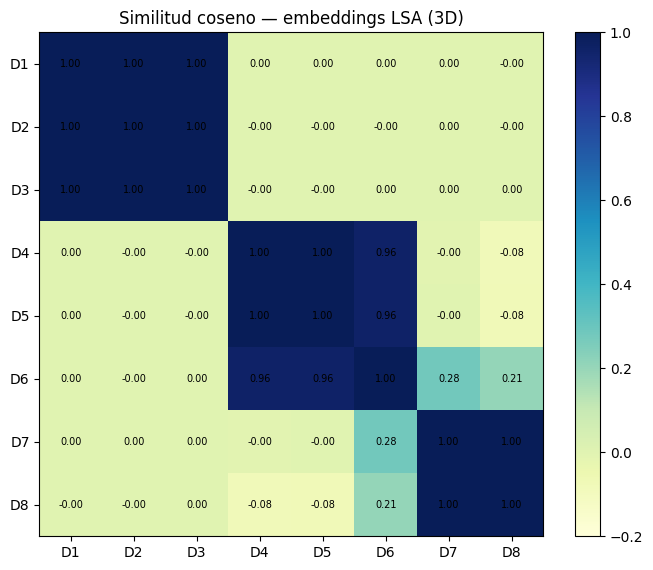

In [8]:
def heatmap(matriz, titulo):
    fig, ax = plt.subplots(figsize=(7, 5.8))
    im = ax.imshow(matriz, cmap="YlGnBu", vmin=-0.2, vmax=1)
    ax.set_xticks(range(len(ids))); ax.set_yticks(range(len(ids)))
    ax.set_xticklabels(ids); ax.set_yticklabels(ids)
    ax.set_title(titulo)
    for i in range(len(ids)):
        for j in range(len(ids)):
            ax.text(j, i, f"{matriz[i,j]:.2f}", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout(); plt.show()

heatmap(cosine_similarity(X_tfidf), "Similitud coseno — TF-IDF")
heatmap(cosine_similarity(X_lsa), "Similitud coseno — embeddings LSA (3D)")


**Lectura.** En TF-IDF, D4 y D5 (dos avisos de vivienda) se parecen (~0.40) y D4 vs D7 (deporte) queda en 0: no comparten términos. En LSA el coseno **intra-tema** sube cerca de 1.0 y el **inter-tema** se queda ~0.02. La reducción de dimensión agrupa documentos del mismo tema aunque no compartan todas las palabras.


## 7. Visualización PCA y búsqueda por consulta


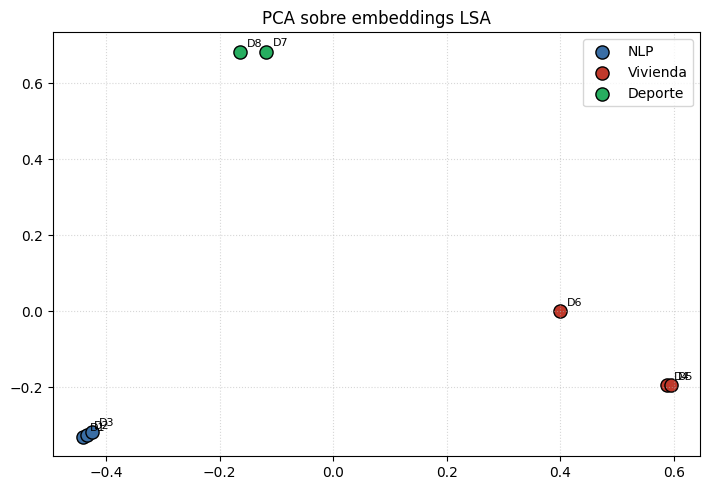

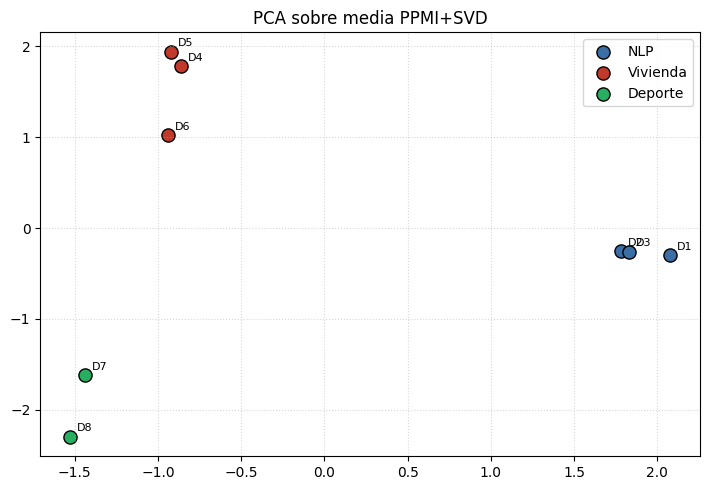

In [9]:
def scatter_pca(X, titulo):
    xy = PCA(n_components=2, random_state=SEED).fit_transform(X)
    colores = {"NLP": "#3a6ea5", "Vivienda": "#c0392b", "Deporte": "#27ae60"}
    fig, ax = plt.subplots(figsize=(7.2, 5))
    for tema in ["NLP", "Vivienda", "Deporte"]:
        m = np.array(temas) == tema
        ax.scatter(xy[m, 0], xy[m, 1], c=colores[tema], s=90, label=tema, edgecolors="k")
    for i, lab in enumerate(ids):
        ax.annotate(lab, xy[i], textcoords="offset points", xytext=(5, 4), fontsize=8)
    ax.set_title(titulo); ax.legend(); ax.grid(True, ls=":", alpha=0.5)
    plt.tight_layout(); plt.show()

scatter_pca(X_lsa, "PCA sobre embeddings LSA")
scatter_pca(X_ppmi, "PCA sobre media PPMI+SVD")


In [10]:
consulta = "Necesito un apartamento de tres habitaciones con parqueadero en Bogotá"
q = svd.transform(tfidf.transform([normalizar(consulta)]).toarray())
sims = cosine_similarity(q, X_lsa)[0]
ranking = pd.DataFrame({
    "id": ids,
    "tema": temas,
    "texto": df["texto"],
    "coseno_LSA": np.round(sims, 4),
}).sort_values("coseno_LSA", ascending=False)
print("Consulta:", consulta)
ranking.reset_index(drop=True)


Consulta: Necesito un apartamento de tres habitaciones con parqueadero en Bogotá


,id,tema,texto,coseno_LSA
0,D5,Vivienda,Busco un apartamento residencial con parqueade...,0.9998
1,D4,Vivienda,El apartamento en Bogotá tiene tres habitacion...,0.9997
2,D6,Vivienda,La casa en arriendo en Bogotá incluye tres hab...,0.9656
3,D7,Deporte,El equipo de fútbol ganó el partido con dos go...,0.0219
4,D3,NLP,Word2Vec y BERT aprenden embeddings y represen...,-0.0000
5,D2,NLP,Los embeddings de lenguaje natural representan...,-0.0000
6,D1,NLP,El procesamiento de lenguaje natural convierte...,0.0000
7,D8,Deporte,Los jugadores del equipo de fútbol entrenaron ...,-0.0553


Los tres primeros puestos son **D5, D4 y D6** (vivienda), con cosenos ≈ 1.00, 1.00 y 0.97. Los de NLP y deporte quedan cerca de 0. Eso es exactamente el uso práctico de un embedding: recuperar documentos **por significado de la consulta**, no por coincidencia exacta de la frase.

**Límite honesto.** El corpus es didáctico (8 oraciones). En producción se usarían embeddings contextuales (BERT, modelos sentence-transformers) sobre miles de documentos. El *pipeline* —limpiar, vectorizar, densificar, comparar— es el mismo.


## 8. Conclusiones

1. Transformar texto en embeddings es pasar de símbolos a un **espacio métrico** donde el coseno mide semántica.
2. One-hot y TF-IDF son el primer paso, pero sufren de **escasez y dimensionalidad** (|V| alta, similitud 0 si no hay solapamiento léxico).
3. LSA y PPMI+SVD **comprimen** a 3 dimensiones y separan temas (intra ≈ 0.99 vs inter ≈ 0.02 en este laboratorio).
4. Una consulta de vivienda ranking-ea avisos de vivienda y no crónicas deportivas: evidencia de que el vector sirve para **búsqueda**.
5. El código es modular (`normalizar`, SVD, coseno, PCA), corre en Colab sin claves de API y está en GitHub.

### Referencias

- Deerwester, S., Dumais, S. T., Furnas, G. W., Landauer, T. K., y Harshman, R. (1990). Indexing by latent semantic analysis. *JASIS, 41*(6), 391–407.
- Jurafsky, D., y Martin, J. H. (2023). *Speech and language processing* (3.ª ed. en borrador).
- Mikolov, T., Chen, K., Corrado, G., y Dean, J. (2013). Efficient estimation of word representations in vector space. *ICLR*.
- Pennington, J., Socher, R., y Manning, C. D. (2014). GloVe: Global vectors for word representation. *EMNLP*.
- Salton, G., y Buckley, C. (1988). Term-weighting approaches in automatic text retrieval. *IP&M, 24*(5), 513–523.

